<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8012/blob/main/laboratorio_calificado_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MCD8012 - Vision Computacional

# LABORATORIO CALIFICADO 1

José Carlos Nomberto

## Importar de Librerias

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## EJERCICIO 1 : Segmentación de frutas por color (RGB y HSV)

### 1. Cargar la imagen y visualizarla en el formato RGB correcto.

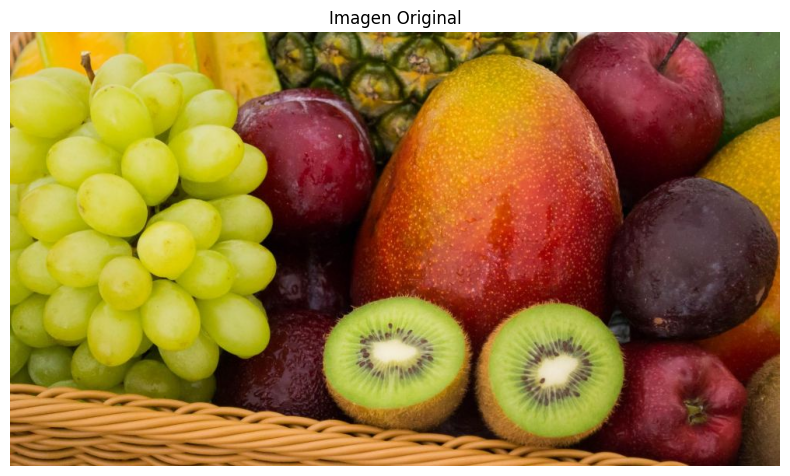

In [ ]:
# Cargar la imagen original
img_bgr = cv2.imread('imagen_ejercicio_1.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Mostrar imagen original
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(img_rgb)
ax.set_title('Imagen Original')
ax.axis('off')
plt.tight_layout()
plt.show()

### 2. Convertir la imagen a un espacio de color HSV.

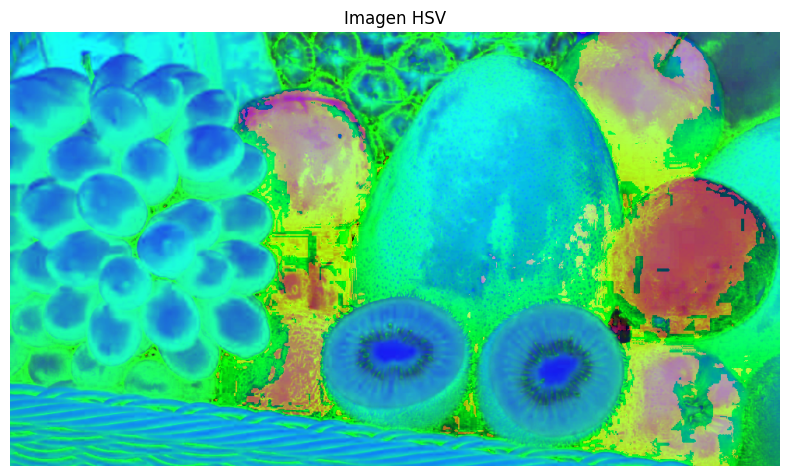

In [ ]:
#### Convertir la imagen a HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Mostrar imagen HSV
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(img_hsv)
ax.set_title('Imagen HSV')
ax.axis('off')
plt.tight_layout()
plt.show()

### 3. Visualizar las bandas R, G, B, H, S, y V.

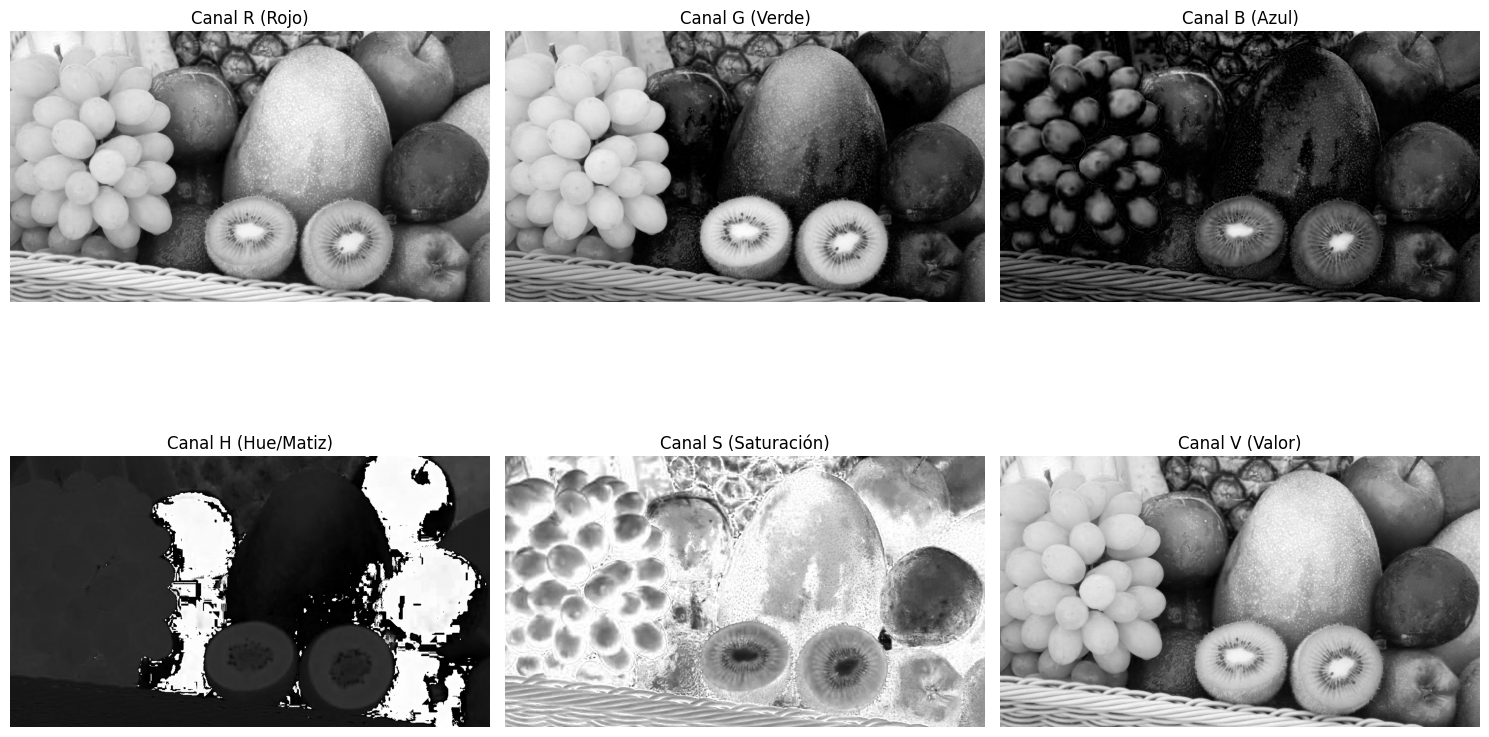

In [ ]:

# Bandas RGB
R, G, B = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]
# Bandas HSV
H, S, V = img_hsv[:,:,0], img_hsv[:,:,1], img_hsv[:,:,2]

# Graficar los canales individuales para análisis
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
channels = [R, G, B, H, S, V]
titles = ['Canal R (Rojo)', 'Canal G (Verde)', 'Canal B (Azul)',
          'Canal H (Hue/Matiz)', 'Canal S (Saturación)', 'Canal V (Valor)']

for i, ax in enumerate(axs.flat):
    ax.imshow(channels[i], cmap='gray')
    ax.set_title(titles[i])
    ax.axis('off')
plt.tight_layout()
plt.show()
plt.savefig('ejercicio1_canales_rgb_hsv.png')
plt.close()


### 4. Umbrales y Máscaras

In [ ]:
# Máscaras de Hue, Saturación y Valor
mask_hue = ((H >= 0) & (H <= 10)) | ((H >= 150) & (H <= 180))
mask_sat = (S >= 60) & (S <= 180)
mask_val = (V >= 30) & (V <= 95)

# Intersección Lógica (&): El píxel debe cumplir simultáneamente las tres condiciones
mask_boolean = mask_hue & mask_sat & mask_val

# Convertir la matriz booleana a formato binario uint8 (0 o 255) para OpenCV
mask_final = mask_boolean.astype(np.uint8) * 255


#### Extracción de Bordes con Canny
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
bordes_canny = cv2.Canny(img_gray, 50, 150)


### 5. Visualizar Máscara e Imagen

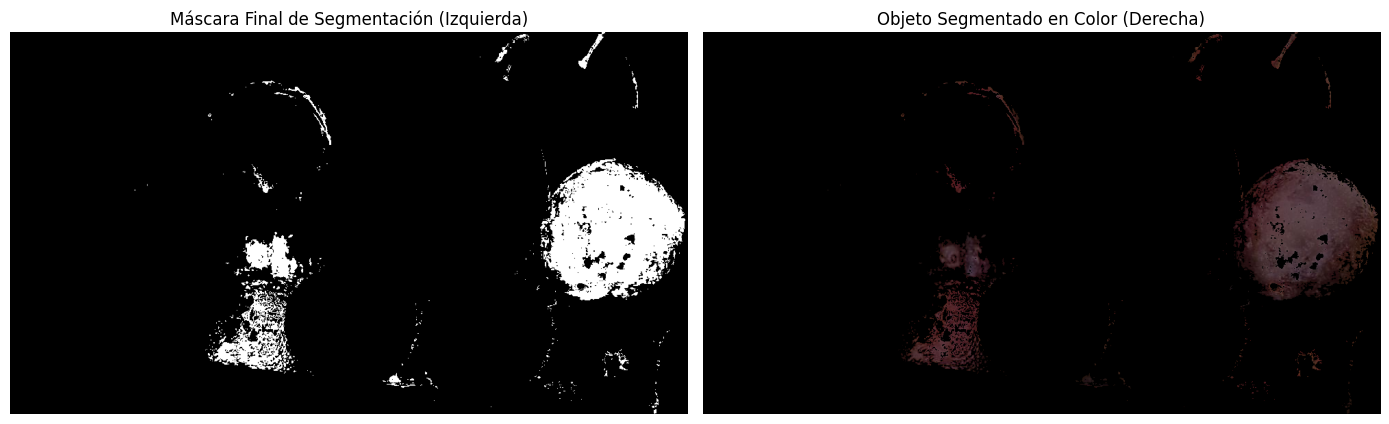

In [ ]:
# Aplicamos la máscara final sobre la imagen RGB original
segmented_img = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_final)

# Graficamos la máscara e imagen filtrada
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Izquierda: Máscara final
ax[0].imshow(mask_final, cmap='gray')
ax[0].set_title('Máscara Final de Segmentación (Izquierda)')
ax[0].axis('off')

# Derecha: Ciruela filtrada
ax[1].imshow(segmented_img)
ax[1].set_title('Objeto Segmentado en Color (Derecha)')
ax[1].axis('off')

plt.tight_layout()
plt.show()
plt.savefig('ejercicio1_segmentacion_ciruela.jpg')
plt.close()

### 6. Explicar el criterio empleado



El criterio fue acotae de forma tridimensional en el espacio HSV, explotando las debilidades ópticas de las frutas competidoras (manzanas, piña y mango) y resaltando la firma única de la ciruela de la derecha:
1. **Filtro del Matiz (H) mediante Unión Lógica (|):**
En la representación de OpenCV, el espectro del color morado/guinda oscuro se encuentra dividido en una discontinuidad: se ubica tanto al final del canal $H$ ($150 \le H \le 180$) como al inicio del mismo ($0 \le H \le 10$). Para capturar la fruta completa sin fragmentaciones, se aplicó una unión lógica (operador OR) que unificó ambos extremos del espectro cromático en una sola condición bi-dimensional.
2. **Filtro de Brillo mediante Intersección Lógica (&):**
Para eliminar la piña y el mango (altamente reflectivas y de colores claros), cuyos  píxeles poseen un valor alto de brillo ($V$) y por el contrario, filtrar la ciruela morada (opaca), se usa la condición $V \le 95$.
3. **Filtro de Saturación:** Se aplicó un rango intermedio ($60 \le S \le 180$) para eliminar los píxeles grises del fondo o sombras profundas de la canasta que, por azar matemático, compartieran niveles bajos de brillo pero que carecieran de pigmentación real.

Finalmente, al intersectar (&) estas tres sub-máscaras de manera simultánea, obligamos al algoritmo a validar únicamente los píxeles que cumplieran con la cromaticidad, pureza y oscuridad exacta de la ciruela.

¿Qué ventajas observas al trabajar en HSV frente a RGB para segmentar colores?

Entre las ventajas que se observan al usar HSV sobre RGB, podemos comentar:

1. **Desacoplamiento de la Luminancia**
    En el espacio RGB, la información del color y la información de la luz están mezcladas en los tres canales, por lo que si un objeto recibe una sombra o un brillo directo, los valores de $R$, $G$ y $B$ se afectan de forma simultánea. En HSV, este problema no se presenta ya que se separa la intensidad de la luz (Value) y la pureza del color (Saturation) del tinte real (Hue). Por ello, se puede filtrar la ciruela por el color en el canal $H$ constante, y variando el canal $V$ para absorber la sombra.

2. **Separación Lineal y Dimensional de los Colores**
    En RGB, para aislar el morado de la ciruela del rojo de las manzanas de al lado, se deben usar hiperplanos o cubos de decisión tridimensionales muy complejos, ya que las dos frutas tienen alto componente en la banda Red. Por otro lado, en HSV, el rojo cálido (manzana) se posiciona al inicio del canal ($H \approx 0-10$), mientras que el morado/púrpura (ciruela) se encuentra en el extremo opuesto ($H \approx 150-160$). Se reduce el problema de segmentación de un espacio tridimensional uno lineal (el canal H).

3. **Representación Intuitiva y Semántica de los Datos**
    Es intuitivo definir rangos basados en cómo entendemos el color, como por ejemplo: "color verde, opaco y oscuro", lo cual se traduce directamente en rangos fijos para $H$, $S$ y $V$. En RGB, determinar qué proporción exacta de tres luces de colores genera lo mismo es un proceso no intuitivo de prueba y error.





    

## EJERCICIO 2 : Detección de bordes en radiografía

### 1. Cargar la imagen, convertirla a escala de grises y visualizarla.

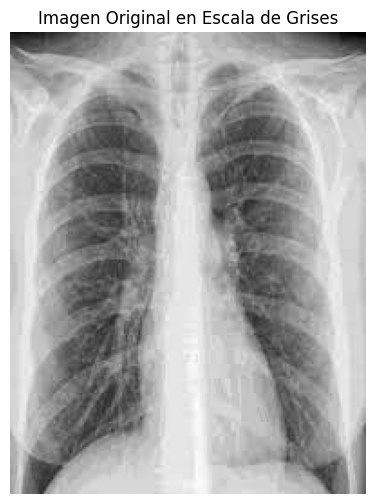

In [ ]:
# Cargar la imagen médica
img_bgr = cv2.imread('imagen_ejercicio_2.jpg')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Visualizar Imagen Original en Escala de Grises
plt.figure(figsize=(6, 6))
plt.imshow(img_gray, cmap='gray')
plt.title('Imagen Original en Escala de Grises')
plt.axis('off')
plt.show()

### 2. Aplicar los filtros para reducción de ruido que considere más adecuados (media, mediana o gaussiano).

In [ ]:
# Aplicar filtro Gaussiano para reducción de ruido

#img_blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)
img_blurred = cv2.GaussianBlur(img_gray, (9, 9), 0)

### 3. Visualizar la imagen mejorada con los filtros de reducción de ruido.

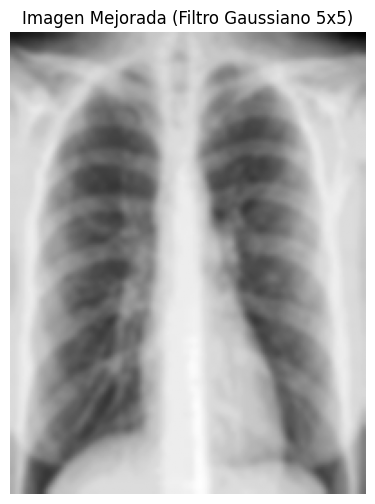

In [ ]:
# Visualizar imagen mejorada

plt.figure(figsize=(6, 6))
plt.imshow(img_blurred, cmap='gray')
plt.title('Imagen Mejorada (Filtro Gaussiano 5x5)')
plt.axis('off')
plt.show()

### 4. Aplicar los operadores Sobel y Canny para la detección de bordes.

In [ ]:
#### OPERADOR SOBEL
# Calculo de gradientes horizontales (Dx) y verticales (Dy)
sobel_ksize = 7
sobel_x = cv2.Sobel(img_blurred, cv2.CV_64F, 1, 0, ksize=sobel_ksize)
sobel_y = cv2.Sobel(img_blurred, cv2.CV_64F, 0, 1, ksize=sobel_ksize)

# Calculo de la magnitud del gradiente: sqrt(Dx^2 + Dy^2)
sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
# Normalización a rango 0-255
sobel_normalized = np.uint8(np.absolute(sobel_magnitude) * 255 / np.max(sobel_magnitude))


#### OPERADOR CANNY

# Umbral inferior: 30, Umbral superior: 90
bordes_canny = cv2.Canny(img_blurred, 30, 90)


### 5. Visualizar, comparar los resultados de ambas técnicas y seleccionar la que considere mejor.


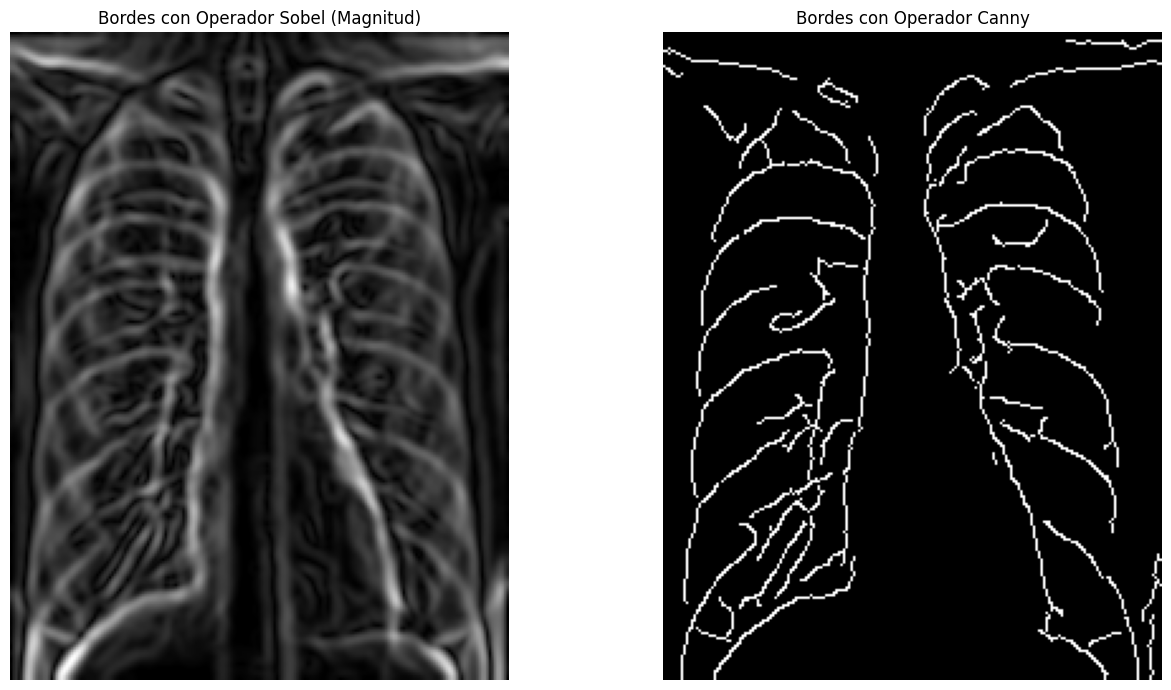

In [ ]:
# Visuzalizar y comparar resultados

fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Izquierda: Magnitud de Sobel
ax[0].imshow(sobel_normalized, cmap='gray')
ax[0].set_title('Bordes con Operador Sobel (Magnitud)')
ax[0].axis('off')

# Derecha: Bordes delgados de Canny
ax[1].imshow(bordes_canny, cmap='gray')
ax[1].set_title('Bordes con Operador Canny')
ax[1].axis('off')

plt.tight_layout()
plt.show()

### 6. Explicar el criterio empleado para seleccionar el/los filtro(s) y el operador de bordes, y responder a la pregunta de reflexión.

Se aplicaron los siguientes criterios:


1.   **Selección del Filtro Gaussiano:** La imagen de una radiografía presenta variaciones de alta frecuencia debidas a la trama vascular pulmonar y al grano de la captura. Debido a que se busca reducir el ruido general granular y se prefiere una imagen más "suave", aceptando cierta pérdida de nitidez, el filtro gaussiano fue el escogido. Luego de probar con kernel de $5 \times 5$, $7 \times 7$, $9 \times 9$ y $11 \times 11$,  el valor óptimo idóneo fue $9 \times 9$ porque actúa como un filtro de paso bajo que atenúa las texturas suaves de los órganos internos, preservando los cambios de intensidad más gruesos correspondientes en los bordes de las costillas.
2.   ** Análisis Estructural con Sobel:** Al evaluar la magnitud de Sobel, se observa gradiente difuso y grueso, debido a que el hueso de la costilla no es una línea, sino una estructura tridimensional con densidad decreciente en sus bordes. El valor óptimo de kernel fue de 7, para permitir trazar los bordes de las costillas asilandolos del tejido pulmonar.
3.   **Análisis de Conectividad con Canny:** El criterio principal para la elección final se basó en el objetivo de alimentar un programa que contará y medirá longitudes. Por ello se obtuvieron los valores óptimos de 30 y 90 para delinear los bordes de las costillas




.





#### Pregunta de reflexión
¿Cuál operador te dio un mejor resultado? ¿Por qué?

Para los objetivos de conteo automatizado y cálculo de longitudes anatómicas, el operador Canny proporciona un resultado superior frente a Sobel debido a:


1. **Adelgazamiento de Bordes:** Sobel genera bandas de gradientes anchas y difusas. Si el programa posterior intenta medir la longitud de una costilla basándose en Sobel, calculará un área o registrará múltiples bordes paralelos para el mismo hueso. Canny reduce el gradiente a líneas delgada, permitiendo un cálculo de longitud directo.

2. **Umbralización por Histéresis:** Las costillas varían en densidad y contraste a medida que cruzan los pulmones y la columna vertebral. Sobel sufre fragmentación en las zonas donde el contraste disminuye. Canny, por el sistema de doble umbral (alto y bajo), es capaz de mantener la conectividad de la línea de la costilla siempre que esté conectada a un punto de borde fuerte.

A pesar de obtener mejores resultados con Canny, se debe tener en cuenta que aún se registra "ruido" o bordes espurios en la zona central (columna vertebral) y en las clavículas.

## EJERCICIO 3 : Segmentación de señales de tránsito por color y bordes

### 1. Cargar la imagen y visualizarla en el formato RGB correcto

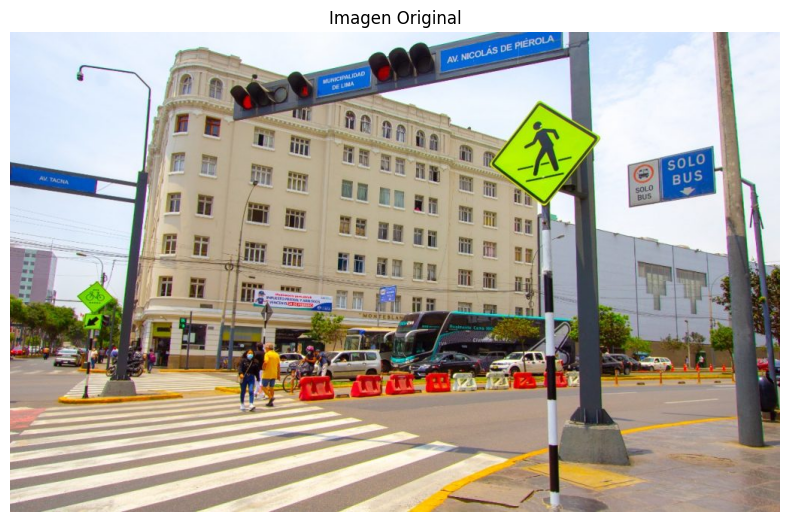

In [34]:
# Cargar imagen

img_bgr = cv2.imread('imagen_ejercicio_3.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Visualizar imagen original
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(img_rgb)
ax.set_title('Imagen Original')
ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Convertir la imagen a un espacio de color HSV

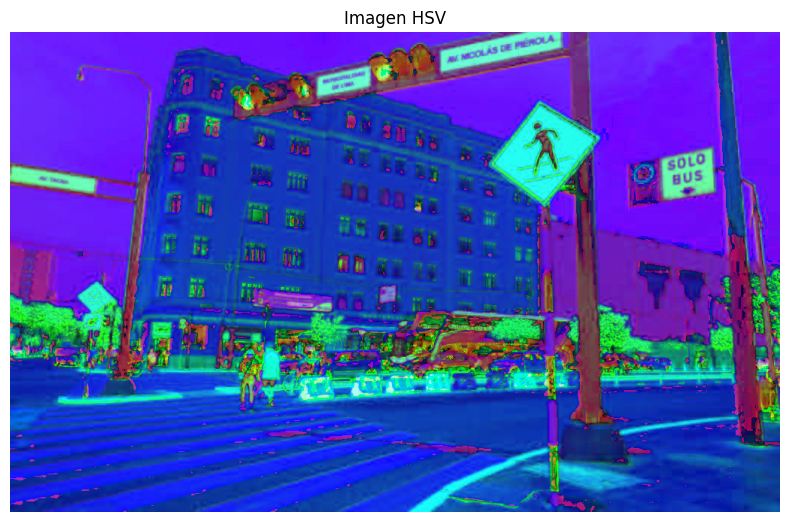

In [35]:
#### Convertir la imagen a HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Mostrar imagen HSV
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(img_hsv)
ax.set_title('Imagen HSV')
ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Visualizar las bandas R, G, B, H, S, y V.

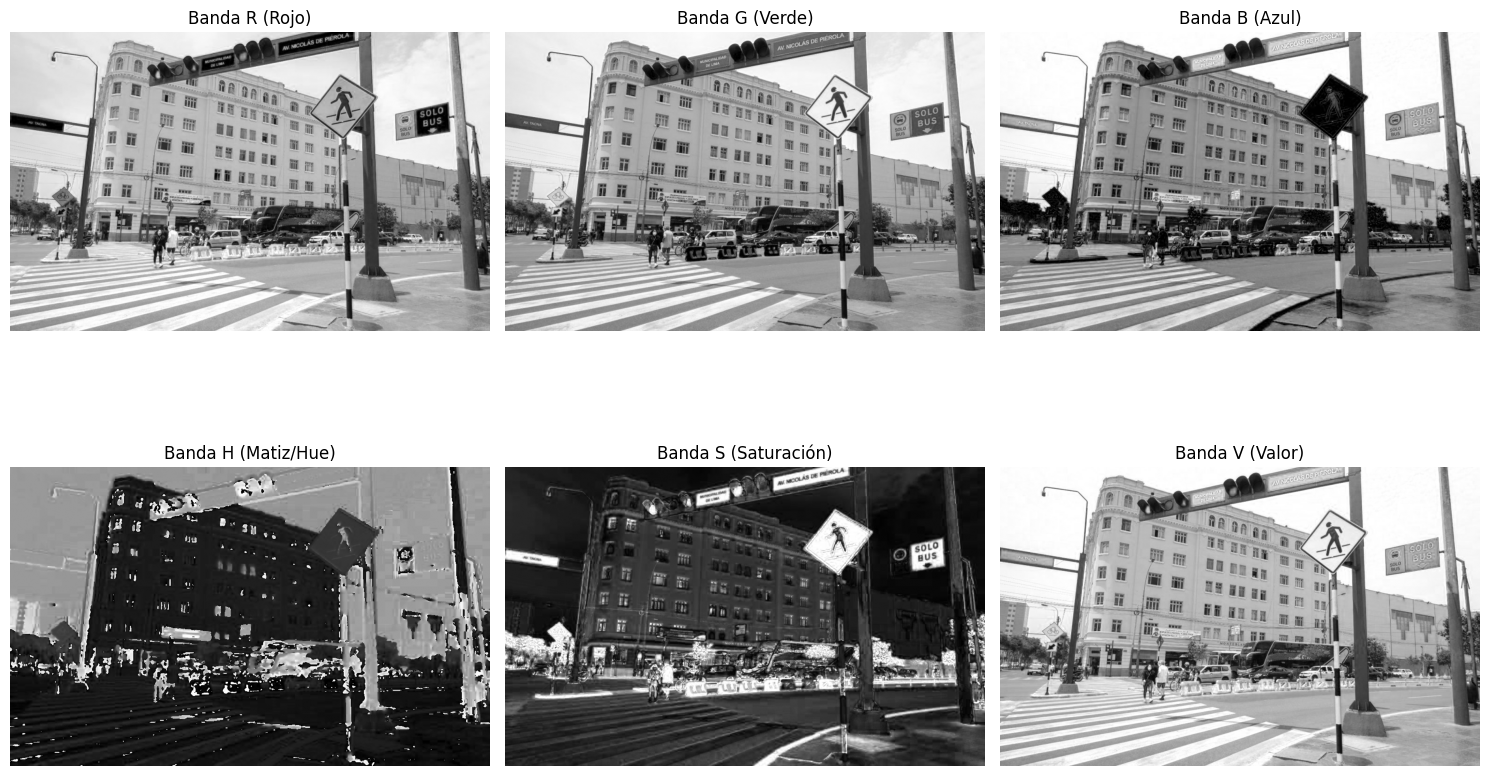

In [36]:
# Extraer bandas RGB
R, G, B = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]

# Extraer bandas HSV
H, S, V = img_hsv[:,:,0], img_hsv[:,:,1], img_hsv[:,:,2]

# Visualizar las bandas R, G, B, H, S, V
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
canales = [R, G, B, H, S, V]
titulos = ['Banda R (Rojo)', 'Banda G (Verde)', 'Banda B (Azul)',
           'Banda H (Matiz/Hue)', 'Banda S (Saturación)', 'Banda V (Valor)']

for i, ax in enumerate(axs.flat):
    ax.imshow(canales[i], cmap='gray')
    ax.set_title(titulos[i])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Experimentar con diferentes umbrales

Para poder segmentar de la mejor forma la señal de ciclovía. Recuerde que puede combinar las máscaras binarias como crea conveniente (*).

In [37]:
# Segmentación por color mediante Operaciones Lógicas en NumPy

# Filtro de Matiz (H): El verde fosforescente/amarillento de la señal [55, 80]
# mask_hue = (H >= 55) & (H <= 80)
mask_hue = (H >= 35) & (H <= 50)

# Filtro de Saturación (S): CRÍTICO. Exigimos S >= 100 para descartar la
# vegetación de los árboles (que es un verde más opaco y lavado).
mask_sat = (S >= 100)

# Filtro de Valor/Brillo (V): Nos asegura capturar la señal iluminada en primer plano
mask_val = (V >= 50)

# INTERSECCIÓN LÓGICA (&): El píxel debe cumplir simultáneamente las 3 condiciones
#mask_boolean = mask_hue & mask_sat & mask_val
mask_color_ch = mask_hue

# Convertimos la matriz booleana de NumPy a formato binario uint8 de 8 bits (0 o 255)
# mask_color = mask_boolean.astype(np.uint8) * 255
mask_color = np.uint8(mask_boolean*255)

## 5. Visualizar la imagen original RGB vs la máscara de segmentación por color

A la derecha la imagen RGB y a la izquierda la máscara de segmentación de este paso
Opcional: Si desea puede combinarlas a través de una multiplicación de la máscara con cada una de las bandas de color para únicamente mostrar en color los objetos segmentados

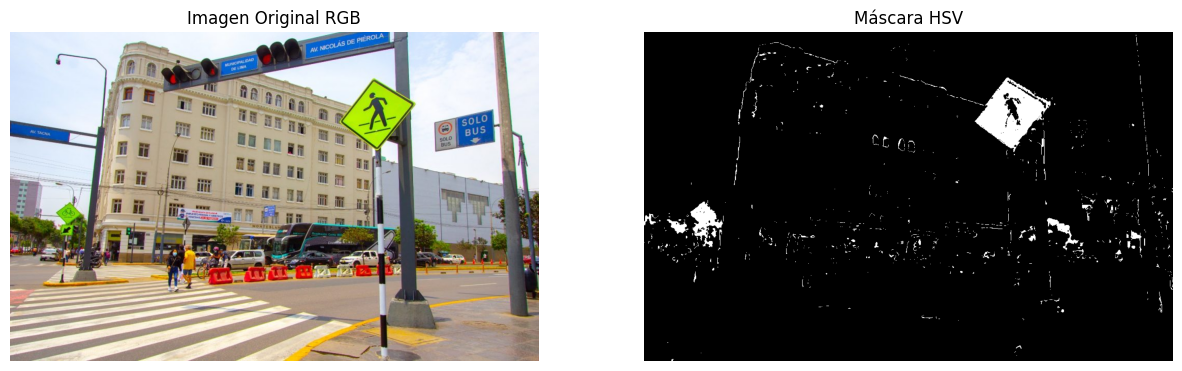

In [32]:
fig = plt.figure(figsize=(15, 10))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Imagen Original RGB')
plt.subplot(1,2,2)
plt.imshow(mask_color,cmap='gray')
plt.axis('off')
plt.title('Máscara HSV')
plt.show()

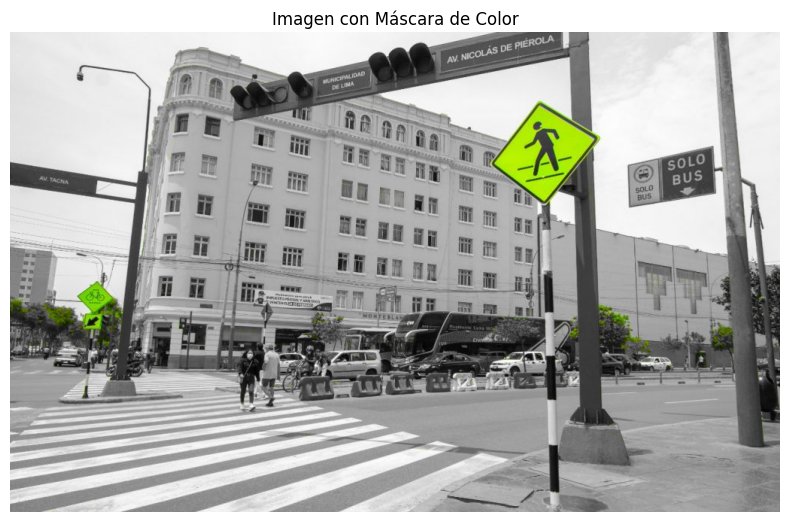

In [39]:
# Multiplicar la mascara por cada banda de color

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_gray = np.multiply(img_gray, np.logical_not(mask_color_ch))
img_gray_3ch = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)

img_mask_R = np.multiply(R,mask_color_ch)
img_mask_G = np.multiply(G,mask_color_ch)
img_mask_B = np.multiply(B,mask_color_ch)

img_with_mask = cv2.merge([img_mask_B, img_mask_G, img_mask_R]) + img_gray_3ch
img_with_mask_rgb = cv2.cvtColor(img_with_mask, cv2.COLOR_BGR2RGB)

# Mostrar imagen con la máscara de color
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(img_with_mask_rgb)
ax.set_title('Imagen con Máscara de Color')
ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Explicar el criterio empleado para segmentar la señal de tránsito por color.

Se usaron mapas de colores para identificar los valores de la señal en HSV y crear una máscara con reglas por canal. Luego, la mascara se aplico a la imagen en escala de grises y en color para su visualizacion.

## 7. Aplicar el operador de Canny para la detección de bordes

Sobre la máscara de segmentación por color y experimentar con los parámetros del operador

In [ ]:
img_3_maskH1 = H > 43
img_3_maskH2 = H < 52
img_3_maskS1 = S > 210
img_3_maskS2 = S < 249
img_3_maskV1 = V > 140
img_3_maskV2 = V < 215

mask_street_ch = (img_3_maskH1 & img_3_maskH2) & (img_3_maskS1 & img_3_maskS2) & (img_3_maskV1 & img_3_maskV2)
mask_street = np.uint8(mask_street_ch*255)

## 8. 8. Visualizar la imagen original en formato RGB, la máscara de segmentación por color y la máscara de bordes

Opcional: Si desea puede combinarlas a través de una multiplicación de la máscara con cada una de las bandas de color para únicamente mostrar en color los objetos segmentados.

## 9. Analizar y responder a la pregunta de reflexión.

### Pregunta de reflexión
¿Qué efecto tiene modificar el umbral del operador Canny?